In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('D:/VNUK ASSIGNMENTS/GRAD/adaptive-selection-tsfm-meta-learning')

In [17]:
import pandas as pd

from src.evaluation.pilot import run_pilot_benchmark
from src.models.moirai import Moirai2Forecaster

In [18]:
MODEL_NAME = "moirai2"
DATASET_NAME = "ETTh1"

CONTEXT_LENGTH = 512
PREDICTION_LENGTHS = [24, 96, 192]
N_WINDOWS = 20
COLUMNS = ["OT"]

In [19]:
forecaster = Moirai2Forecaster()
forecaster

Loading Moirai-2 from Salesforce/moirai-2.0-R-small on cuda
Moirai-2 loaded
Quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [20]:
metrics = run_pilot_benchmark(
    forecaster=forecaster,
    dataset_name=DATASET_NAME,
    context_length=CONTEXT_LENGTH,
    prediction_lengths=PREDICTION_LENGTHS,
    n_windows=N_WINDOWS,
    columns=COLUMNS)


- Moirai2Forecaster  •  Dataset: ETTh1  •  Horizon: 24  •  Windows: 20
Window 00 - MASE: 0.3793 - 0.03s
Window 01 - MASE: 0.6889 - 0.04s
Window 02 - MASE: 1.7620 - 0.06s
Window 03 - MASE: 0.5832 - 0.04s
Window 04 - MASE: 0.4894 - 0.05s
Window 05 - MASE: 0.5531 - 0.03s
Window 06 - MASE: 0.3922 - 0.02s
Window 07 - MASE: 0.2811 - 0.02s
Window 08 - MASE: 0.3328 - 0.03s
Window 09 - MASE: 1.0200 - 0.02s
Window 10 - MASE: 0.5728 - 0.02s
Window 11 - MASE: 0.3287 - 0.02s
Window 12 - MASE: 2.0442 - 0.02s
Window 13 - MASE: 0.3770 - 0.03s
Window 14 - MASE: 0.2596 - 0.03s
Window 15 - MASE: 1.5609 - 0.03s
Window 16 - MASE: 0.9397 - 0.03s
Window 17 - MASE: 0.3262 - 0.02s
Window 18 - MASE: 1.0139 - 0.02s
Window 19 - MASE: 0.4323 - 0.02s

- Moirai2Forecaster  •  Dataset: ETTh1  •  Horizon: 96  •  Windows: 20
Window 00 - MASE: 1.7922 - 0.04s
Window 01 - MASE: 1.6108 - 0.04s
Window 02 - MASE: 0.8233 - 0.04s
Window 03 - MASE: 0.9135 - 0.04s
Window 04 - MASE: 1.4070 - 0.04s
Window 05 - MASE: 1.5245 - 0.04

In [21]:
metrics.head()

,dataset,model,target,window_id,cutoff_timestamp,context_length,prediction_length,mae,rmse,smape,mase,inference_time_seconds
0,ETTh1,moirai2,OT,0,2018-06-06 19:00:00,512,24,0.507914,0.551669,4.649150,0.379346,0.032279
1,ETTh1,moirai2,OT,1,2018-06-07 19:00:00,512,24,0.883215,1.184088,8.303150,0.688865,0.036913
2,ETTh1,moirai2,OT,2,2018-06-08 19:00:00,512,24,1.960423,2.859233,26.274504,1.762020,0.055006
3,ETTh1,moirai2,OT,3,2018-06-09 19:00:00,512,24,0.681244,0.727616,8.667937,0.583212,0.044509
4,ETTh1,moirai2,OT,4,2018-06-10 19:00:00,512,24,0.594895,0.862742,6.003594,0.489419,0.049702


In [22]:
expected_rows = N_WINDOWS * len(PREDICTION_LENGTHS)

print(f"Expected rows: {expected_rows}")
print(f"Actual rows:   {len(metrics)}")

assert len(metrics) == expected_rows

Expected rows: 60
Actual rows:   60


In [23]:
mase_summary = (
    metrics
    .groupby("prediction_length", as_index=False)["mase"]
    .mean()
    .round(4))
mase_summary

,prediction_length,mase
0,24,0.7169
1,96,1.3402
2,192,1.5242


In [24]:
metrics.groupby("prediction_length").mean(numeric_only=True).round(4)

,window_id,context_length,mae,rmse,smape,mase,inference_time_seconds
prediction_length,,,,,,,
24,9.5,512.0,0.8878,1.1660,10.3205,0.7169,0.0288
96,9.5,512.0,2.2457,2.6104,25.4285,1.3402,0.0427
192,9.5,512.0,2.6027,3.0864,49.2037,1.5242,0.0669


In [25]:
output_dir = PROJECT_ROOT / "results" / "pilot" / "ETTh1"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "moirai2.csv"
metrics.to_csv(output_path, index=False)
print(f"Saved to: {output_path.relative_to(PROJECT_ROOT).as_posix()}")

Saved to: results/pilot/ETTh1/moirai2.csv


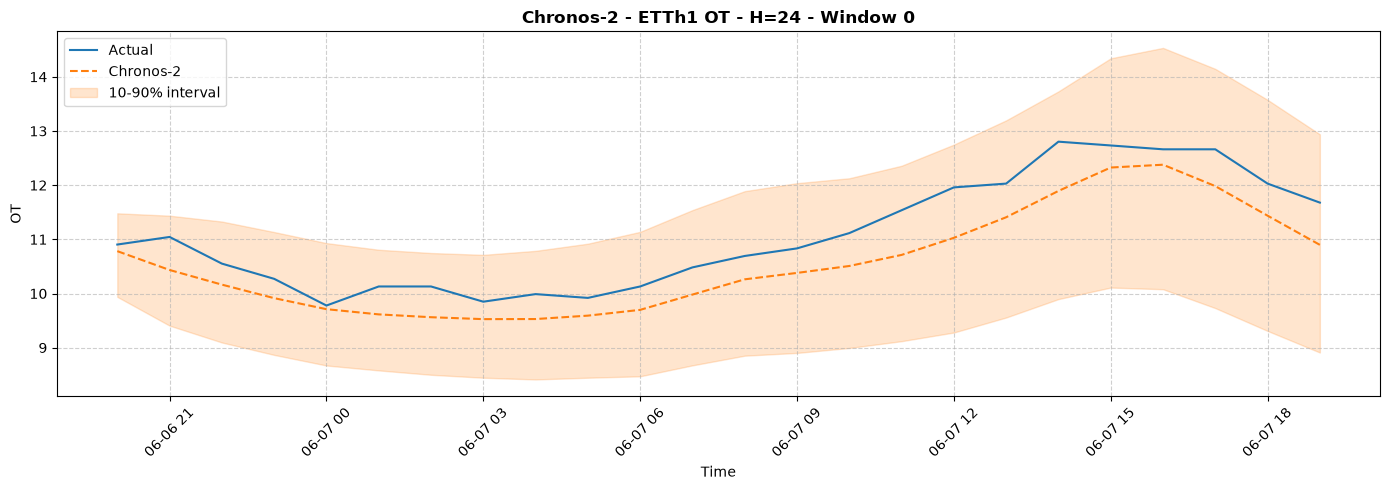

Saved figure: results\pilot\figures\moirai2_ETTh1_OT_h24_window0.png


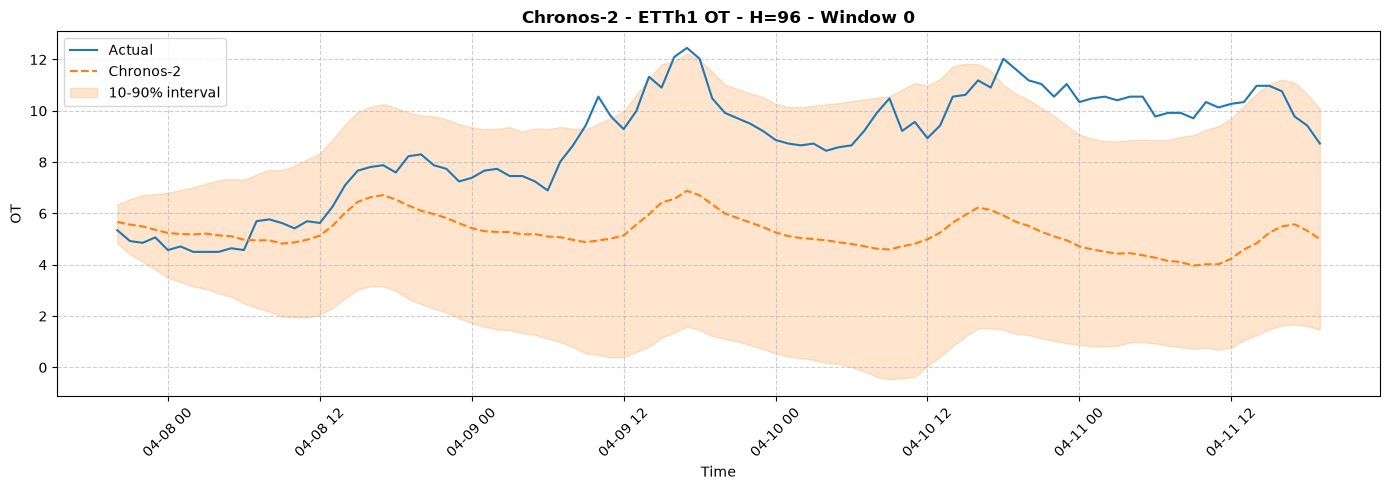

Saved figure: results\pilot\figures\moirai2_ETTh1_OT_h96_window0.png


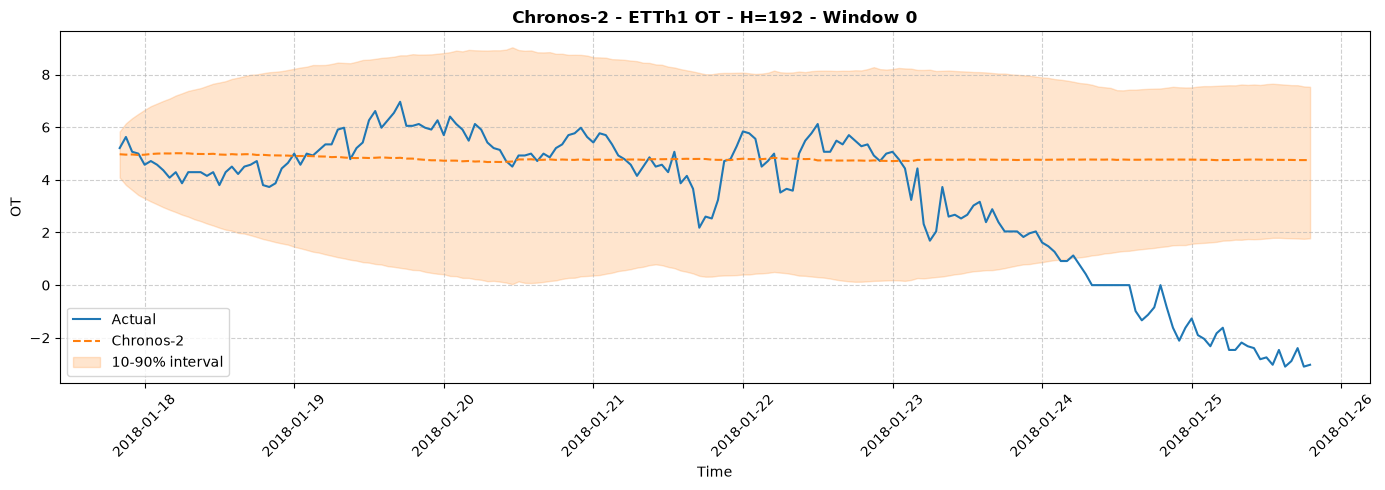

Saved figure: results\pilot\figures\moirai2_ETTh1_OT_h192_window0.png


In [26]:
import matplotlib.pyplot as plt

PLOT_HORIZONS = PREDICTION_LENGTHS
PLOT_WINDOW_ID = 0
PLOT_VARIABLE = "OT"

forecasts_path = PROJECT_ROOT / "results" / "pilot" / "forecasts" / f"{MODEL_NAME}_{DATASET_NAME}.parquet"
forecasts = pd.read_parquet(forecasts_path)
figures_dir = PROJECT_ROOT / "results" / "pilot" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

for PLOT_HORIZON in PLOT_HORIZONS:
    ot = forecasts.loc[
        (forecasts["prediction_length"] == PLOT_HORIZON)
        & (forecasts["window_id"] == PLOT_WINDOW_ID)
        & (forecasts["variable"] == PLOT_VARIABLE)].copy()
    ot["timestamp"] = pd.to_datetime(ot["timestamp"])
    ot = ot.sort_values("timestamp")
    if ot.empty:
        raise ValueError(f"No saved forecast matches H={PLOT_HORIZON}, window={PLOT_WINDOW_ID}, variable={PLOT_VARIABLE}.")

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(ot["timestamp"], ot["actual"], color="tab:blue", label="Actual")
    ax.plot(ot["timestamp"], ot["prediction"], color="tab:orange", linestyle="--", label="Chronos-2")
    if {"lower", "upper"}.issubset(ot.columns):
        ax.fill_between(
            ot["timestamp"], ot["lower"], ot["upper"],
            color="tab:orange", alpha=0.2, label="10-90% interval")
    ax.set_title(
        f"Chronos-2 - {DATASET_NAME} {PLOT_VARIABLE} - H={PLOT_HORIZON} - Window {PLOT_WINDOW_ID}",
        fontweight="bold")
    ax.set_xlabel("Time")
    ax.set_ylabel(PLOT_VARIABLE)
    ax.legend()
    ax.grid(True, alpha=0.6, linestyle="--")
    plt.xticks(rotation=45)
    fig.tight_layout()

    figure_path = figures_dir / f"{MODEL_NAME}_{DATASET_NAME}_{PLOT_VARIABLE}_h{PLOT_HORIZON}_window{PLOT_WINDOW_ID}.png"
    fig.savefig(figure_path)
    plt.show()
    plt.close(fig)
    print(f"Saved figure: {figure_path.relative_to(PROJECT_ROOT)}")